In [33]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
dataset_base = "E:\\AI ML Projects\\AI ML Course\\Mini Projects\\5. Tumor Analysis\\Tumour" 
splits = ["train", "valid", "test"]

for split in splits:
    print(f"\n--- {split.upper()} SET ---")
    split_path = os.path.join(dataset_base, split)
    
    # List tumor types
    categories = [cat for cat in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, cat))]
    print(f"Tumor types: {categories}")
    
    # Count images per category
    category_counts = {}
    for category in categories:
        cat_path = os.path.join(split_path, category)
        image_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        category_counts[category] = len(image_files)
    
    print("Number of images per category:", category_counts)


--- TRAIN SET ---
Tumor types: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of images per category: {'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}

--- VALID SET ---
Tumor types: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of images per category: {'glioma': 161, 'meningioma': 124, 'no_tumor': 99, 'pituitary': 118}

--- TEST SET ---
Tumor types: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of images per category: {'glioma': 80, 'meningioma': 63, 'no_tumor': 49, 'pituitary': 54}


In [27]:
from PIL import Image
import os

dataset_root = r"E:\AI ML Projects\AI ML Course\Mini Projects\5. Tumor Analysis\Tumour"
subfolders = ["train", "valid", "test"]

def get_image_size(path):
    try:
        with Image.open(path) as img:
            return img.size  # width, height
    except:
        print("❌ Could not open:", path)
        return None

all_sizes = []

for sub in subfolders:
    sub_path = os.path.join(dataset_root, sub)

    for cls in os.listdir(sub_path):
        cls_path = os.path.join(sub_path, cls)

        # ✅ Skip anything that is NOT a folder
        if not os.path.isdir(cls_path):
            continue

        for file in os.listdir(cls_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(cls_path, file)

                size = get_image_size(path)
                if size:
                    all_sizes.append(size)

print("\nUnique resolutions in dataset:")
print(set(all_sizes))

print("\nTotal images checked:", len(all_sizes))


Unique resolutions in dataset:
{(640, 640)}

Total images checked: 2443


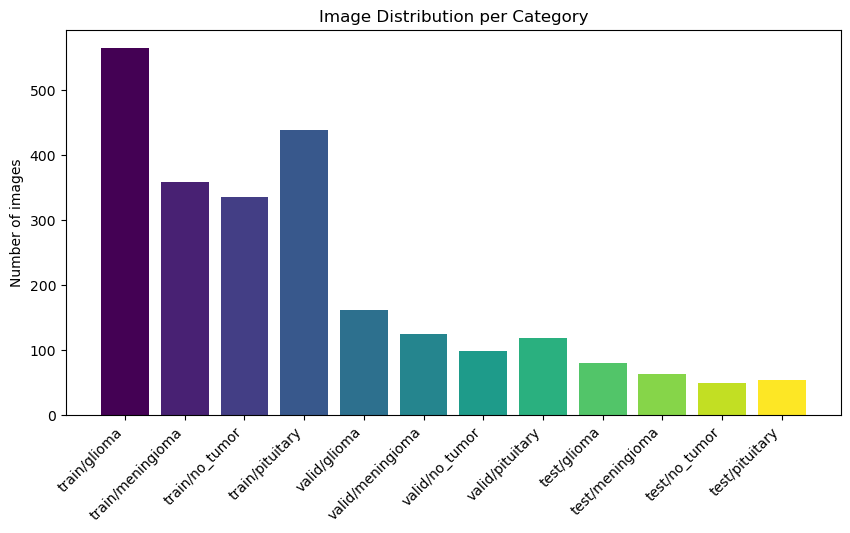

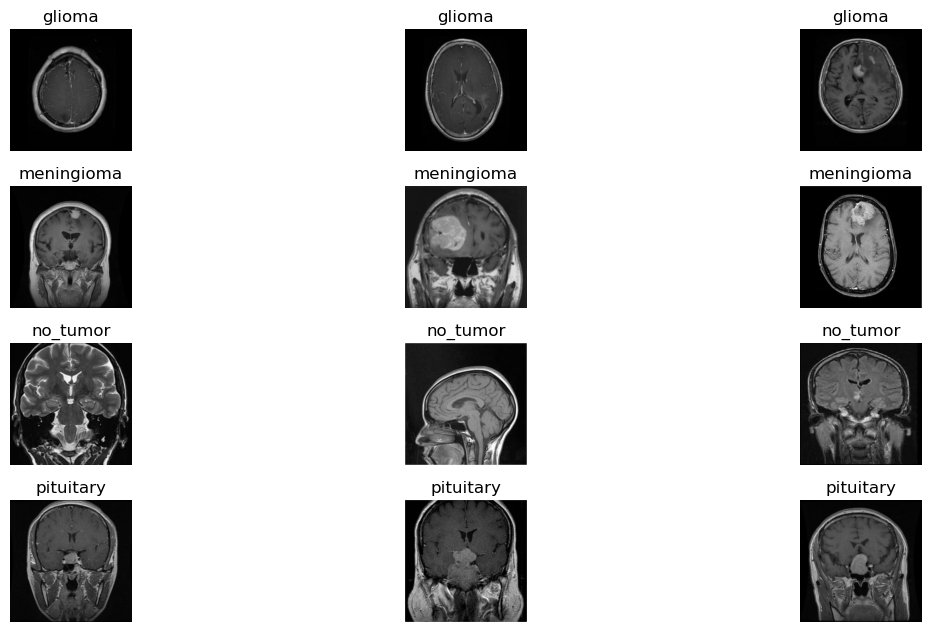

In [32]:
dataset_root = r"E:\AI ML Projects\AI ML Course\Mini Projects\5. Tumor Analysis\Tumour"
subfolders = ["train", "valid", "test"]

# 1️⃣ Count images per category
category_counts = {}

for sub in subfolders:
    sub_path = os.path.join(dataset_root, sub)
    for cls in os.listdir(sub_path):
        cls_path = os.path.join(sub_path, cls)
        if not os.path.isdir(cls_path):
            continue
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        category_counts[f"{sub}/{cls}"] = count

# 2️⃣ Plot distribution with proper colors
plt.figure(figsize=(10,5))
colors = cm.viridis(np.linspace(0, 1, len(category_counts)))  # list of colors
plt.bar(category_counts.keys(), category_counts.values(), color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Image Distribution per Category")
plt.show()

# 3️⃣ Display sample images from each class (train folder)
train_path = os.path.join(dataset_root, "train")
plt.figure(figsize=(12, 8))

i = 1
for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    if not os.path.isdir(cls_path):
        continue
    sample_files = random.sample(
        [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))],
        min(3, len(os.listdir(cls_path)))
    )
    for file in sample_files:
        path = os.path.join(cls_path, file)
        img = Image.open(path)
        plt.subplot(len(os.listdir(train_path)), 3, i)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        i += 1

plt.tight_layout()
plt.show()

In [35]:


dataset_root = r"E:\AI ML Projects\AI ML Course\Mini Projects\5. Tumor Analysis\Tumour"

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixels 0-1
    rotation_range=30,          # Random rotation ±30 degrees
    width_shift_range=0.1,      # Horizontal shift
    height_shift_range=0.1,     # Vertical shift
    shear_range=0.1,            # Shear transformation
    zoom_range=0.1,             # Random zoom
    horizontal_flip=True,       # Horizontal flip
    vertical_flip=False,        # Vertical flip (use with caution)
    brightness_range=[0.8,1.2], # Random brightness adjustment
    fill_mode='nearest',        # Fill empty pixels after transformations
)

# Validation generator: only rescaling, no augmentation
valid_datagen = ImageDataGenerator(rescale=1./255)

# Test generator: only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train data
train_generator = train_datagen.flow_from_directory(
    dataset_root + "/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

# Load validation data
valid_generator = valid_datagen.flow_from_directory(
    dataset_root + "/valid",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    dataset_root + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Input shape: 224x224 RGB images
input_shape = (224, 224, 3)
num_classes = 4  # glioma, meningioma, pituitary, no_tumor

model = Sequential()

# --------------------
# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# --------------------
# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# --------------------
# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# --------------------
# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of the model
model.summary()

D:\Reneta_AI_ML\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,564 (98.37 MB)

 Trainable params: 25,785,604 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [38]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=25,
    batch_size=32
)

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8224 - loss: 0.4665 - val_accuracy: 0.5857 - val_loss: 4.5041
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8307 - loss: 0.4229 - val_accuracy: 0.6514 - val_loss: 3.6232
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8442 - loss: 0.4278 - val_accuracy: 0.2809 - val_loss: 5.9933
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8354 - loss: 0.4213 - val_accuracy: 0.6932 - val_loss: 1.2530
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8442 - loss: 0.4006 - val_accuracy: 0.7112 - val_loss: 1.2217
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8478 - loss: 0.3867 - val_accuracy: 0.6175 - val_loss: 4.4486
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8442 - loss: 0.4209 - val_accuracy: 0.6912 - val_loss: 2.5843
Epoch 8/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8460 - loss: 0.3953 - val_accuracy: 0.7789 - val_loss:

In [39]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_classes = 4
input_shape = (224, 224, 3)

# Load EfficientNetB0 pretrained on ImageNet, exclude top layers
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze base model initially
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step 


In [40]:
# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)        # converts feature map to vector
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Check the model summary
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [41]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,  # start small
    batch_size=32
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 889ms/step - accuracy: 0.2549 - loss: 1.6735 - val_accuracy: 0.2351 - val_loss: 1.5779
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.3080 - loss: 1.5360 - val_accuracy: 0.2351 - val_loss: 1.4908
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.2826 - loss: 1.5448 - val_accuracy: 0.3207 - val_loss: 1.5198
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 996ms/step - accuracy: 0.3168 - loss: 1.4765 - val_accuracy: 0.1972 - val_loss: 1.5055
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3103 - loss: 1.4601 - val_accuracy: 0.3207 - val_loss: 1.4800
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 998ms/step - accuracy: 0.3386 - loss: 1.4232 - val_accuracy: 0.3207 - val_loss: 1.4571
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.3245 - loss: 1.4217 - val_accuracy: 0.2351 - val_loss: 1.5631
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3469 - loss: 1.3845 - val_accuracy: 0.2351 - 

In [42]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10  # fine-tuning epochs
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.2814 - loss: 1.9698 - val_accuracy: 0.3207 - val_loss: 2.1267
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.2578 - loss: 1.9102 - val_accuracy: 0.3207 - val_loss: 2.5911
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.2802 - loss: 1.7820 - val_accuracy: 0.3207 - val_loss: 2.5065
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.3115 - loss: 1.7307 - val_accuracy: 0.3207 - val_loss: 2.3501
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.2991 - loss: 1.7083 - val_accuracy: 0.3207 - val_loss: 2.2139
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.2726 - loss: 1.7983 - val_accuracy: 0.3207 - val_loss: 2.0168
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3139 - loss: 1.6531 - val_accuracy: 0.3207 - val_loss: 1.7823
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3027 - loss: 1.7298 - val_accuracy: 0.3207 - val_loss:

In [44]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Stop training if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Save the best model (weights only) during training
checkpoint = ModelCheckpoint(
    'best_model.h5',          # save path
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [45]:
# Assuming 'model' is your custom CNN and generators are ready
history_cnn = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.2921 - loss: 1.7276 
Epoch 1: val_loss improved from None to 1.46168, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.2814 - loss: 1.6986 - val_accuracy: 0.3207 - val_loss: 1.4617
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.3208 - loss: 1.6938 
Epoch 2: val_loss improved from 1.46168 to 1.43001, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3245 - loss: 1.7180 - val_accuracy: 0.3207 - val_loss: 1.4300
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.3085 - loss: 1.6773 
Epoch 3: val_loss did not improve from 1.43001
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3109 - loss: 1.6667 - val_accuracy: 0.3207 - val_loss: 1.4702
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.3060 - loss: 1.6662 
Epoch 4: val_loss did not improve from 1.43001
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3251 - loss: 1.6629 - val_accuracy: 0.3207 - val_loss: 1.4509
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.3286 - loss: 1.5919 
Epoch 5: val_loss improved from 1.43001 to 1.36239, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3192 - loss: 1.6055 - val_accuracy: 0.3247 - val_loss: 1.3624
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.3176 - loss: 1.6285 
Epoch 6: val_loss did not improve from 1.36239
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3345 - loss: 1.5937 - val_accuracy: 0.3247 - val_loss: 1.3827
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.3549 - loss: 1.6030 
Epoch 7: val_loss did not improve from 1.36239
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3392 - loss: 1.5854 - val_accuracy: 0.3247 - val_loss: 1.3784
Epoch 8/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.3295 - loss: 1.6092 
Epoch 8: val_loss did not improve from 1.36239
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3404 - loss: 1.5747 - val_accuracy: 0.3247 - val_loss: 1.3796
Epoch 9/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.3568 - loss: 1.5710 
Ep


Epoch 9: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3451 - loss: 1.5677 - val_accuracy: 0.3466 - val_loss: 1.3251
Epoch 10/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.3490 - loss: 1.5357 
Epoch 10: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3404 - loss: 1.5269 - val_accuracy: 0.3367 - val_loss: 1.3353
Epoch 11/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.3437 - loss: 1.4833 
Epoch 11: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3327 - loss: 1.5343 - val_accuracy: 0.3526 - val_loss: 1.3292
Epoch 12/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.3571 - loss: 1.4723 
Epoch 12: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3546 - loss: 1.4883 - val_accuracy: 0.3506 - val_loss: 1.3283
Epoch 13/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.3586 - loss: 1.5

In [46]:
# Assuming 'model' is your transfer learning model (EfficientNet, etc.)
history_tl = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,       # initial training with frozen base
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

# Optional: fine-tune top layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.3448 - loss: 1.5643 
Epoch 1: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3363 - loss: 1.5373 - val_accuracy: 0.3267 - val_loss: 1.3959
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.3666 - loss: 1.5069 
Epoch 2: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.3558 - loss: 1.5214 - val_accuracy: 0.3526 - val_loss: 1.3307
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.3428 - loss: 1.5213 
Epoch 3: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3434 - loss: 1.5313 - val_accuracy: 0.3347 - val_loss: 1.3562
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.3507 - loss: 1.4552 
Epoch 4: val_loss did not improve from 1.32514
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3628 - loss: 1.4449 - val_accuracy: 0.3367 - val_loss: 1.3502
Epoc


Epoch 5: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3499 - loss: 1.4946 - val_accuracy: 0.3446 - val_loss: 1.3199
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.3579 - loss: 1.4891 
Epoch 6: val_loss did not improve from 1.31990
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3563 - loss: 1.4912 - val_accuracy: 0.3327 - val_loss: 1.3748
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.3749 - loss: 1.4378 
Epoch 7: val_loss improved from 1.31990 to 1.31068, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3658 - loss: 1.4461 - val_accuracy: 0.3566 - val_loss: 1.3107
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.3717 - loss: 1.4282 
Epoch 8: val_loss improved from 1.31068 to 1.29971, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3699 - loss: 1.4416 - val_accuracy: 0.3645 - val_loss: 1.2997
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.3630 - loss: 1.4300 
Epoch 9: val_loss improved from 1.29971 to 1.29179, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3717 - loss: 1.4472 - val_accuracy: 0.3765 - val_loss: 1.2918
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.3667 - loss: 1.4614 
Epoch 10: val_loss improved from 1.29179 to 1.27691, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3646 - loss: 1.4465 - val_accuracy: 0.3845 - val_loss: 1.2769
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.3602 - loss: 1.4564 
Epoch 11: val_loss did not improve from 1.27691
53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3888 - loss: 1.4060 - val_accuracy: 0.3785 - val_loss: 1.2856
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.3844 - loss: 1.3721  
Epoch 12: val_loss improved from 1.27691 to 1.26086, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.3752 - loss: 1.3858 - val_accuracy: 0.4104 - val_loss: 1.2609
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 996ms/step - accuracy: 0.3464 - loss: 1.4351 
Epoch 13: val_loss did not improve from 1.26086
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.3676 - loss: 1.4080 - val_accuracy: 0.4004 - val_loss: 1.2674
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.3979 - loss: 1.3769 
Epoch 14: val_loss did not improve from 1.26086
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3847 - loss: 1.3684 - val_accuracy: 0.3845 - val_loss: 1.2890
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.3903 - loss: 1.3622 
Epoch 15: val_loss did not improve from 1.26086
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3900 - loss: 1.3671 - val_accuracy: 0.4064 - val_loss: 1.2658
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.3789 - loss: 1.


Epoch 1: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3664 - loss: 1.4046 - val_accuracy: 0.4044 - val_loss: 1.2588
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.3873 - loss: 1.3706 
Epoch 2: val_loss improved from 1.25880 to 1.24640, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3782 - loss: 1.3883 - val_accuracy: 0.4163 - val_loss: 1.2464
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.3768 - loss: 1.3599 
Epoch 3: val_loss did not improve from 1.24640
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 994ms/step - accuracy: 0.3858 - loss: 1.3756 - val_accuracy: 0.4064 - val_loss: 1.2536
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.3743 - loss: 1.3491 
Epoch 4: val_loss did not improve from 1.24640
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 939ms/step - accuracy: 0.3870 - loss: 1.3519 - val_accuracy: 0.3964 - val_loss: 1.2684
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.4188 - loss: 1.3487 
Epoch 5: val_loss did not improve from 1.24640
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 941ms/step - accuracy: 0.3935 - loss: 1.3652 - val_accuracy: 0.3884 - val_loss: 1.2795
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.3686 - loss: 1

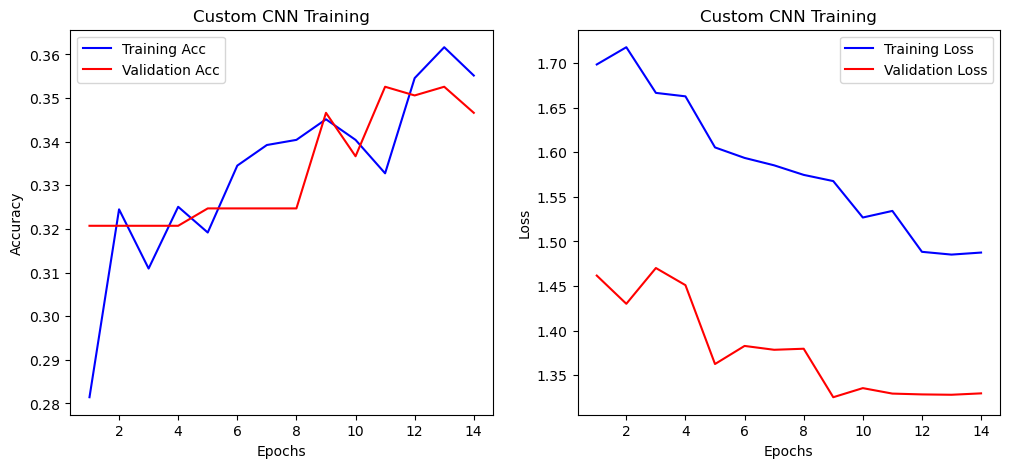

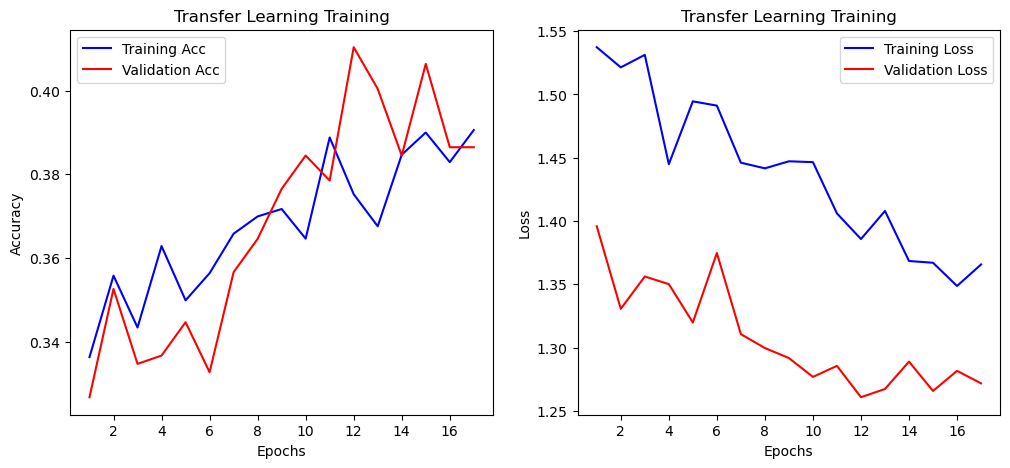

In [47]:

def plot_history(history, title="Model Accuracy & Loss"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Plot for custom CNN
plot_history(history_cnn, "Custom CNN Training")

# Plot for transfer learning
plot_history(history_tl, "Transfer Learning Training")

In [48]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 491ms/step - accuracy: 0.4431 - loss: 1.2416
Test Accuracy: 44.31%


In [49]:
# Get predictions
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = test_generator.classes

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 659ms/step


In [50]:
from sklearn.metrics import classification_report

class_labels = list(test_generator.class_indices.keys())  # ['glioma', 'meningioma', 'pituitary', 'no_tumor']

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

      glioma       0.39      1.00      0.56        80
  meningioma       1.00      0.02      0.03        63
    no_tumor       0.70      0.57      0.63        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.44       246
   macro avg       0.52      0.40      0.31       246
weighted avg       0.52      0.44      0.32       246



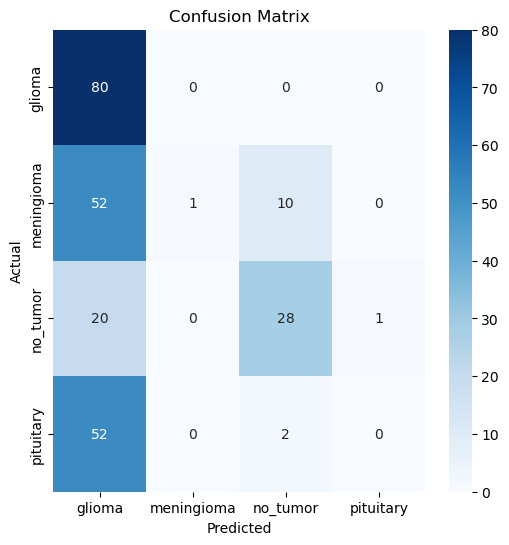

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

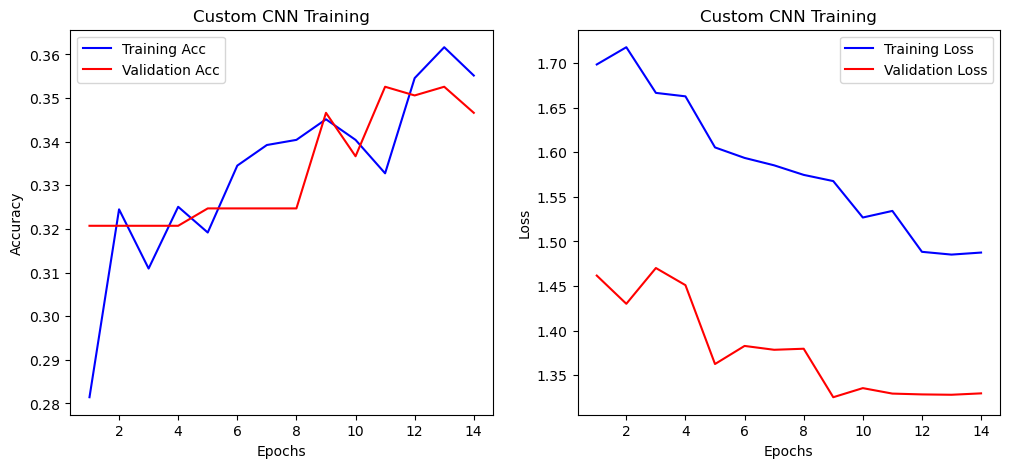

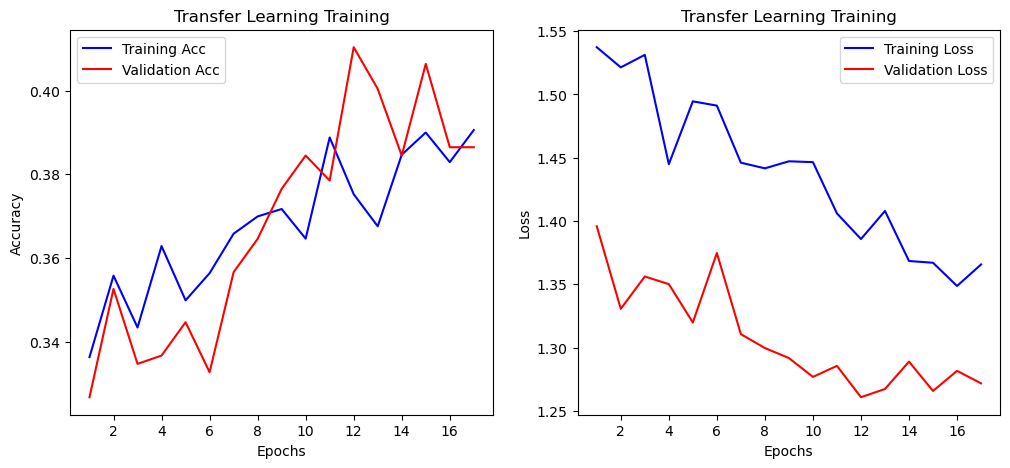

In [52]:
def plot_history(history, title="Model Accuracy & Loss"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Example for custom CNN
plot_history(history_cnn, "Custom CNN Training")

# Example for transfer learning
plot_history(history_tl, "Transfer Learning Training")